In [ ]:
#Import libraries and load dataset:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load dataset (skip metadata rows)
df = pd.read_csv('population_data_csv.csv', skiprows=4)
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            264 non-null    float64
 5   1961            264 non-null    float64
 6   1962            264 non-null    float64
 7   1963            264 non-null    float64
 8   1964            264 non-null    float64
 9   1965            264 non-null    float64
 10  1966            264 non-null    float64
 11  1967            264 non-null    float64
 12  1968            264 non-null    float64
 13  1969            264 non-null    float64
 14  1970            264 non-null    float64
 15  1971            264 non-null    float64
 16  1972            264 non-null    float64
 17  1973            264 non-null    flo

In [5]:
df.shape

(266, 71)

In [6]:
df.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')

In [7]:
df.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
count,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,...,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,0.0,0.0
mean,1.153986e+08,1.170032e+08,1.191639e+08,1.218340e+08,1.245281e+08,1.272539e+08,1.300993e+08,1.329525e+08,1.358805e+08,1.389068e+08,...,3.078413e+08,3.115874e+08,3.152613e+08,3.187768e+08,3.219350e+08,3.250893e+08,3.283978e+08,3.318713e+08,NaN,NaN
std,3.616512e+08,3.661333e+08,3.727667e+08,3.813673e+08,3.900147e+08,3.987681e+08,4.079973e+08,4.172128e+08,4.266920e+08,4.365296e+08,...,9.557272e+08,9.664012e+08,9.767615e+08,9.865558e+08,9.952478e+08,1.003664e+09,1.012445e+09,1.021698e+09,NaN,NaN
min,2.715000e+03,2.970000e+03,3.264000e+03,3.584000e+03,3.922000e+03,4.282000e+03,4.664000e+03,5.071000e+03,5.500000e+03,5.631000e+03,...,1.086900e+04,1.075100e+04,1.058100e+04,1.039900e+04,1.019400e+04,9.992000e+03,9.816000e+03,9.646000e+03,NaN,NaN
25%,5.152028e+05,5.255230e+05,5.363018e+05,5.475875e+05,5.593638e+05,5.675750e+05,5.711695e+05,5.779525e+05,5.825170e+05,5.861185e+05,...,1.791019e+06,1.797086e+06,1.788891e+06,1.790151e+06,1.786079e+06,1.803545e+06,1.827816e+06,1.824359e+06,NaN,NaN
50%,3.659633e+06,3.747132e+06,3.831900e+06,3.919710e+06,4.010150e+06,4.102976e+06,4.198738e+06,4.297792e+06,4.396290e+06,4.503420e+06,...,1.025915e+07,1.028382e+07,1.042338e+07,1.069786e+07,1.050577e+07,1.048694e+07,1.064485e+07,1.090503e+07,NaN,NaN
75%,2.686293e+07,2.761326e+07,2.837302e+07,2.915448e+07,2.995223e+07,3.075921e+07,3.147516e+07,3.203946e+07,3.247057e+07,3.277149e+07,...,6.000225e+07,6.014866e+07,5.972908e+07,6.097280e+07,6.283041e+07,6.471182e+07,6.661761e+07,6.855165e+07,NaN,NaN
max,3.021513e+09,3.062768e+09,3.117372e+09,3.184063e+09,3.251253e+09,3.318998e+09,3.389087e+09,3.459015e+09,3.530704e+09,3.604816e+09,...,7.614523e+09,7.697234e+09,7.778009e+09,7.854748e+09,7.920515e+09,7.989545e+09,8.064058e+09,8.141809e+09,NaN,NaN


In [11]:
# Choose a year (e.g., 2020)
year = '2020'

In [12]:

# Drop missing values
data = df[year].dropna()

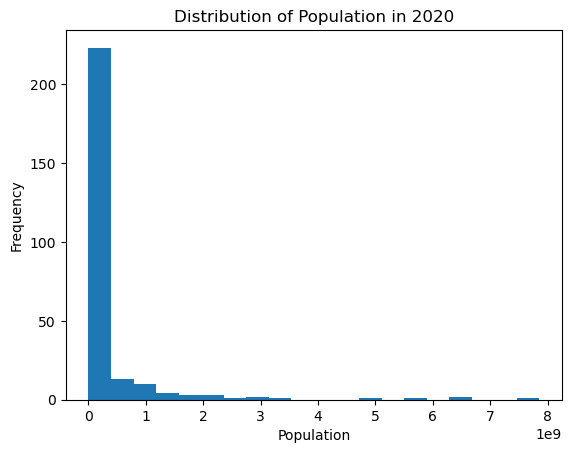

In [13]:
# Create histogram
plt.figure()
plt.hist(data, bins=20)
plt.xlabel('Population')
plt.ylabel('Frequency')
plt.title(f'Distribution of Population in {year}')
plt.show()

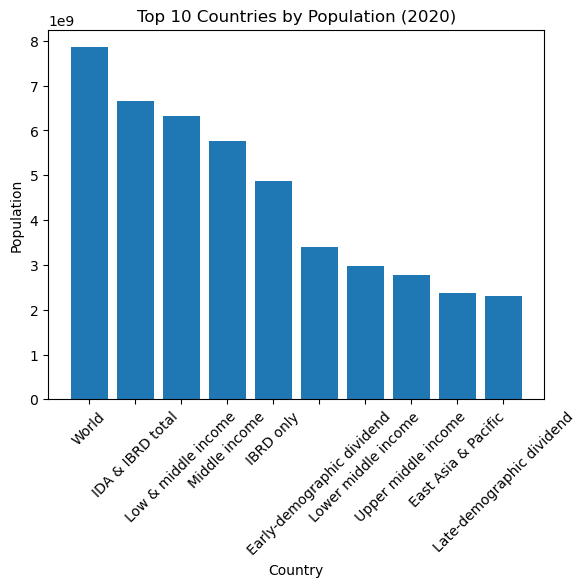

In [16]:
top10 = df[['Country Name', '2020']].dropna().sort_values(by='2020', ascending=False).head(10)

plt.figure()
plt.bar(top10['Country Name'], top10['2020'])
plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Population')
plt.title('Top 10 Countries by Population (2020)')
plt.show()